<a href="https://colab.research.google.com/github/jainybhatt/Credit-card-fraud-detection/blob/main/Credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing necessory libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import recall_score, f1_score

In [2]:
# Importing the dataset

credit_data = pd.read_csv('creditcard.csv')
credit_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
credit_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
# checking the information of dataset

credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Distribution

credit_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
# Check the duplicates in dataset

credit_data.duplicated().sum()

np.int64(1081)

In [7]:
# Check the class values for those duplicated columns

credit_data['Class'][credit_data.duplicated()].value_counts()

,count
Class,
0,1062
1,19


In [8]:
# drop dupicated values and verify

credit_data.drop_duplicates(inplace=True)
credit_data.duplicated().sum()

np.int64(0)

In [9]:
#check for null values

credit_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [10]:
# Drop instances with null value since there is only one and no value for class

credit_data.dropna(inplace=True)
credit_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [11]:
# check distribution for class

credit_data['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998333
1,0.001667


# **Visualization (EDA):**

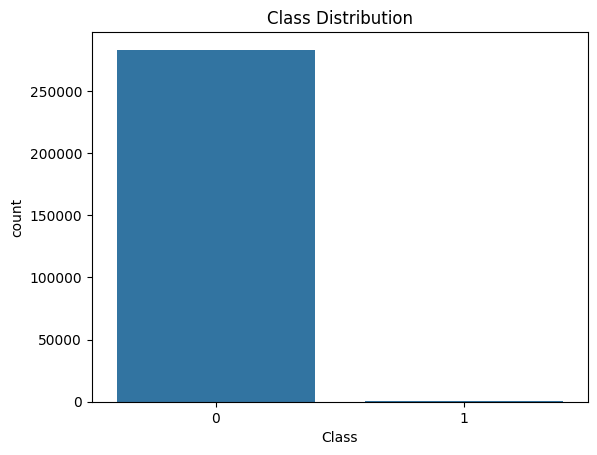

In [12]:
# Class distribution

sns.countplot(x='Class', data=credit_data)
plt.title("Class Distribution")
plt.show()

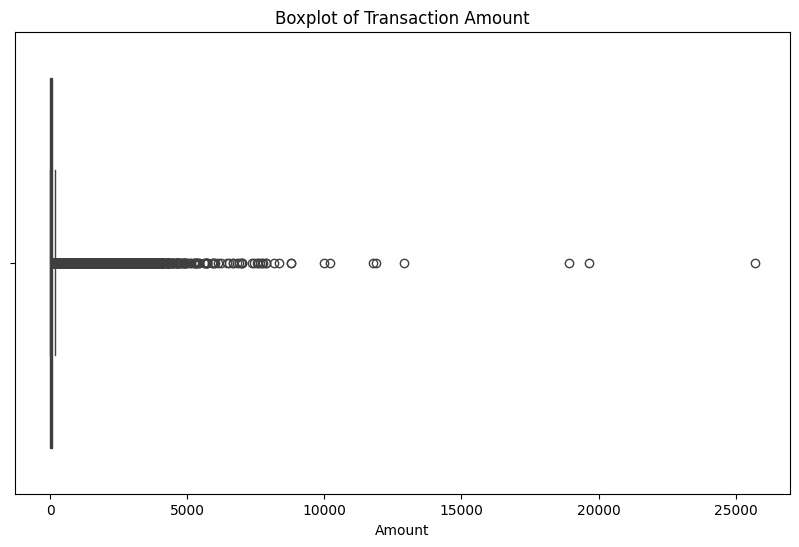

In [13]:
# Boxplot for Amount

plt.figure(figsize=(10, 6))
sns.boxplot(x=credit_data['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Amount')
plt.show()

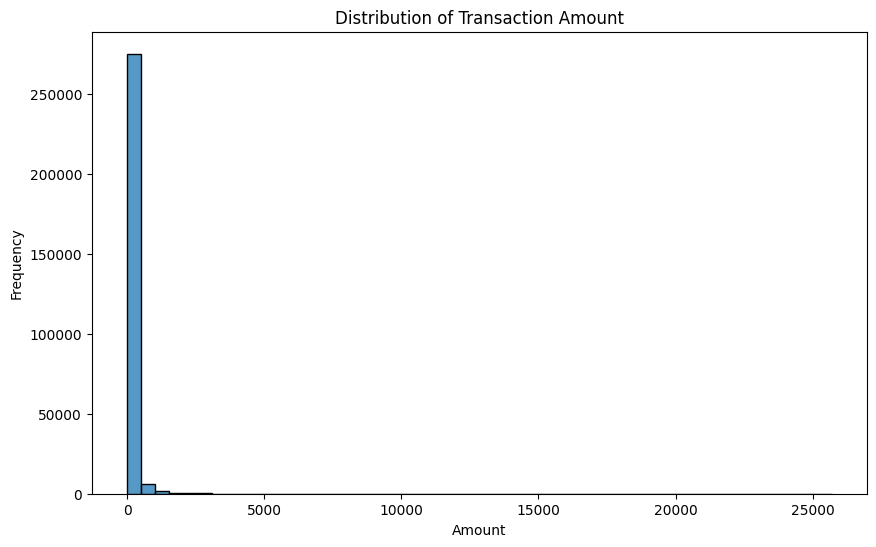

In [14]:
# Distribution plot Amount

plt.figure(figsize=(10, 6))
sns.histplot(credit_data['Amount'], bins=50)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

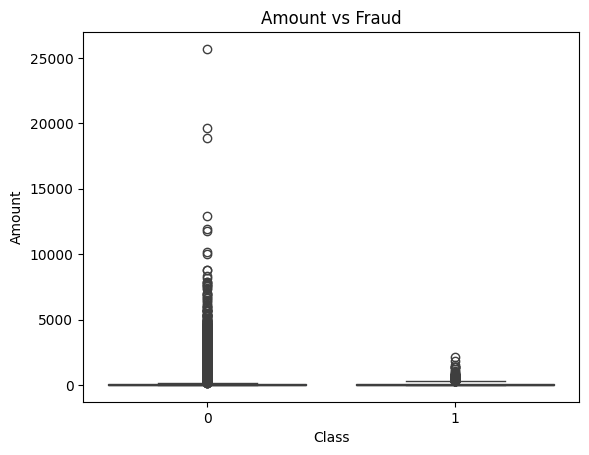

In [15]:
# Fraud vs Non-Fraud Amount

sns.boxplot(x='Class', y='Amount', data=credit_data)
plt.title("Amount vs Fraud")
plt.show()

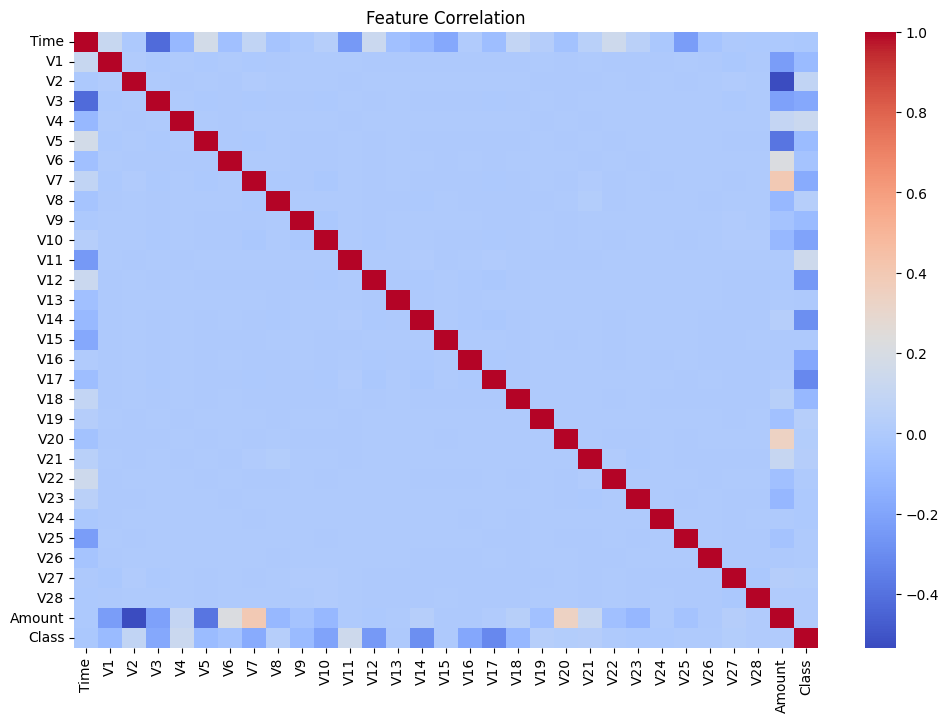

In [16]:
# Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(credit_data.corr() ,cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation")
plt.show()

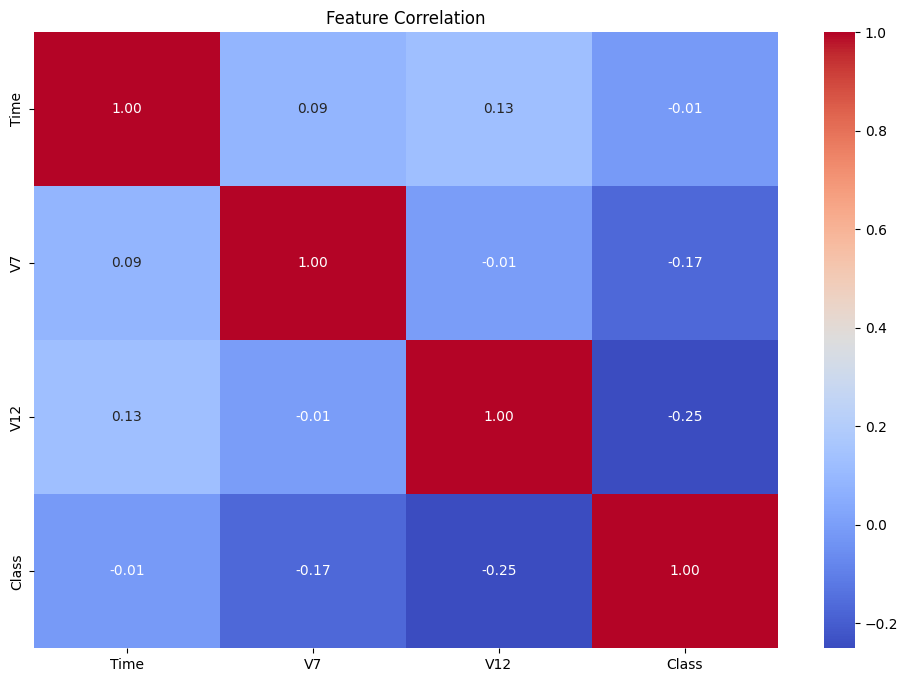

In [17]:
#
plt.figure(figsize=(12,8))
sns.heatmap(credit_data[['Time','V7','V12','Class' ]].corr(), annot = True ,cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation")
plt.show()

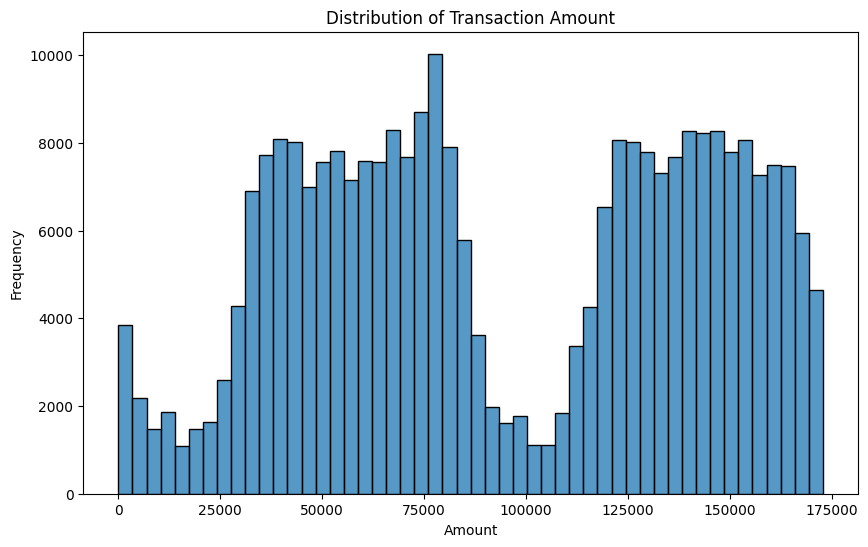

In [18]:
# Distribution plot Amount

plt.figure(figsize=(10, 6))
sns.histplot(credit_data['Time'], bins=50)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

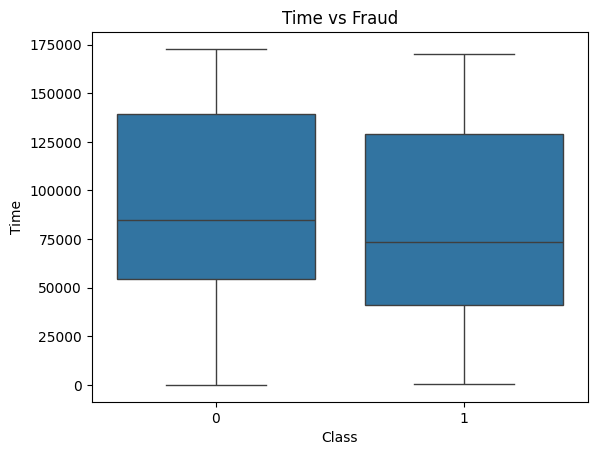

In [19]:
# Fraud vs Non-Fraud Amount

sns.boxplot(x='Class', y='Time', data=credit_data)
plt.title("Time vs Fraud")
plt.show()

In [20]:
# Create a new column 'Hour' from Time for more insides
credit_data['Hour'] = pd.to_datetime(credit_data['Time'], unit='s').dt.hour
credit_data['Hour'].value_counts()

,count
Hour,
21,17629
18,16959
11,16781
20,16705
10,16548
14,16520
16,16396
15,16374
17,16130


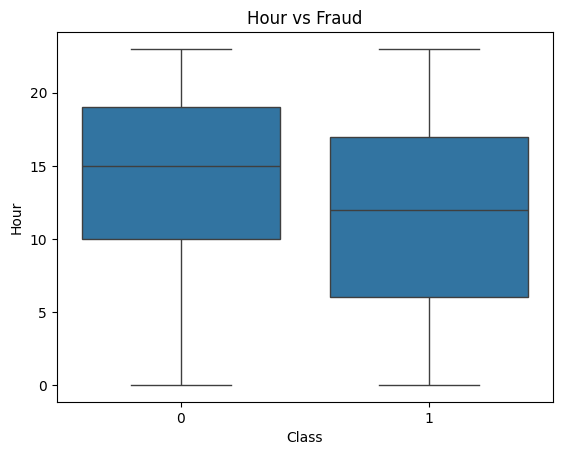

In [21]:
# Fraud vs Non-Fraud Amount

sns.boxplot(x='Class', y='Hour', data=credit_data)
plt.title("Hour vs Fraud")
plt.show()

In [22]:
# Create a sub dataset for only fraud class
fraud_transactions = credit_data[credit_data['Class'] == 1]

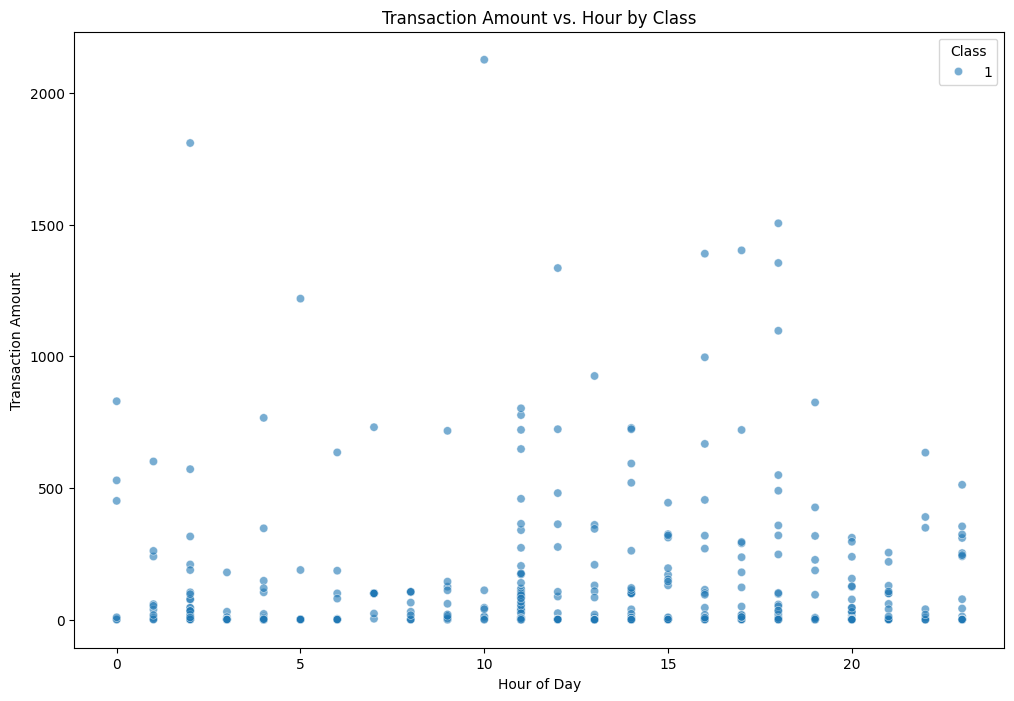

In [23]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Hour', y='Amount', hue='Class', data=fraud_transactions, alpha=0.6)
plt.title('Transaction Amount vs. Hour by Class')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Amount')
plt.show()

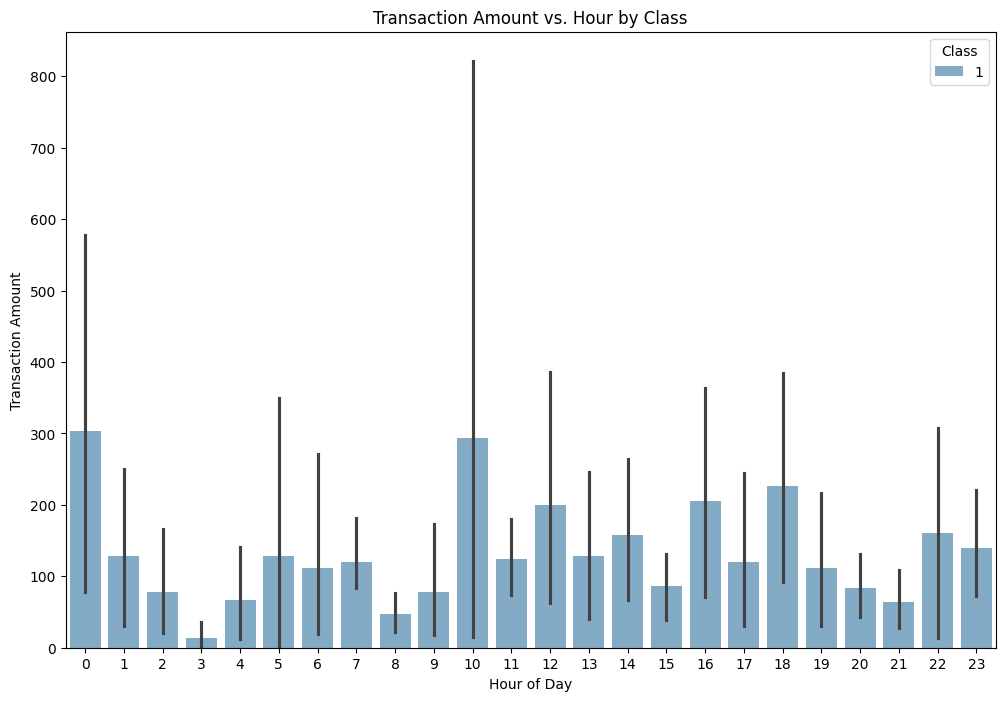

In [24]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Hour', y='Amount', hue='Class', data=fraud_transactions, alpha=0.6)
plt.title('Transaction Amount vs. Hour by Class')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Amount')
plt.show()

In [25]:
average_amounts = credit_data.groupby('Class')['Amount'].mean()
display(average_amounts)

,Amount
Class,
0,88.413575
1,123.871860


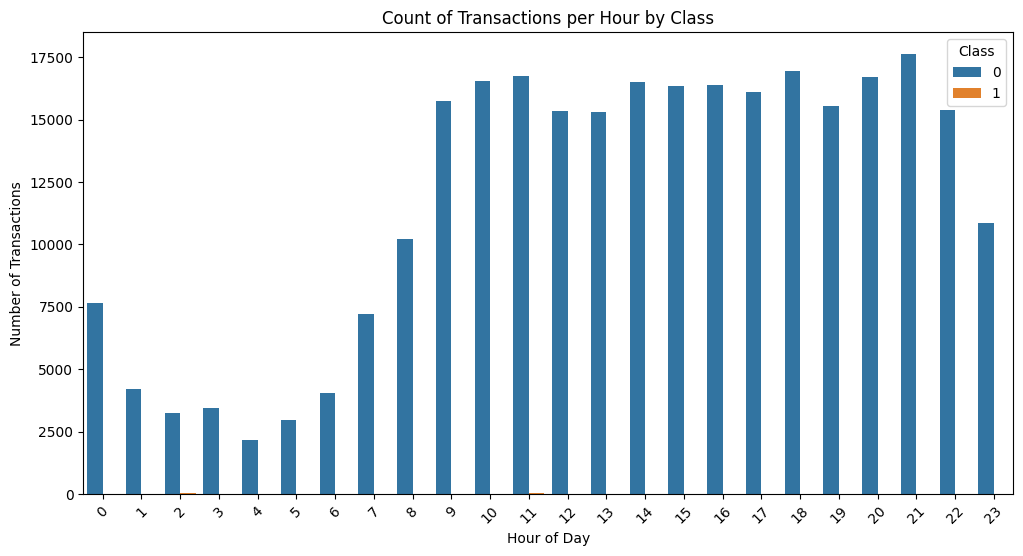

In [26]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Hour', hue='Class', data=credit_data)
plt.title('Count of Transactions per Hour by Class')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

In [27]:
credit_data.to_csv("sample_data/processed_data.csv", index=False)

# **Model Training**

## Base Model

In [28]:
# Preparing the data
df = pd.read_csv("sample_data/processed_data.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

In [29]:
# Splitting the data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=19, stratify=y
)

In [30]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [31]:

y_pred_logreg = model.predict(X_test)
recall_logreg = recall_score(y_test, y_pred_logreg, pos_label=1)
f1_logreg = f1_score(y_test, y_pred_logreg, pos_label=1)

print(f"Recall (Class 1): {recall_logreg}")
print(f"F1-Score (Class 1): {f1_logreg}")


Recall (Class 1): 0.631578947368421
F1-Score (Class 1): 0.75


From llogistic regression we got recall value 0.88 and 0.23 for f1-score.

## Class Weights

In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=10000)
model.fit(X_train, y_train)

In [ ]:
y_pred_bal_logreg = model.predict(X_test)

recall_bal_logreg = recall_score(y_test, y_pred_bal_logreg, pos_label=1)
f1_bal_logreg = f1_score(y_test, y_pred_bal_logreg, pos_label=1)

print(f"Recall (Class 1): {recall_bal_logreg}")
print(f"F1-Score (Class 1): {f1_bal_logreg}")

For balanced class weight we have got 0.89 recall value and 0.11 f1-score to identify fraud.

In [ ]:


smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
model.fit(X_train_res, y_train_res)

In [ ]:
y_pred_smote_logreg = model.predict(X_test)
recall_smote_logreg = recall_score(y_test, y_pred_smote_logreg, pos_label=1)
f1_smote_logreg = f1_score(y_test, y_pred_smote_logreg, pos_label=1)

print(f"Recall (Class 1): {recall_smote_logreg}")
print(f"F1-Score (Class 1): {f1_smote_logreg}")

For balanced class weight we have got 0.88 recall value and 0.23 f1-score to identify fraud.

In [ ]:

rf = RandomForestClassifier(class_weight='balanced', n_estimators=100)
rf.fit(X_train, y_train)

In [ ]:
y_pred_rf = rf.predict(X_test)

recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print(f"Recall (Class 1): {recall_rf}")
print(f"F1-Score (Class 1): {f1_rf}")

For balanced class weight we have got 0.88 recall value and 0.23 f1-score to identify fraud.

In [ ]:

y_probs = model.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_probs)

In [ ]:

# Calculate FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:

# Initialize XGBoost Classifier
# Use scale_pos_weight for handling imbalanced classes
# This is similar to class_weight='balanced'
# The value is usually (count(negative_class) / count(positive_class))
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,
                          scale_pos_weight=scale_pos_weight_value, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

In [ ]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

recall_xgb = recall_score(y_test, y_pred_xgb, pos_label=1)
f1_xgb = f1_score(y_test, y_pred_xgb, pos_label=1)

print(f"Recall (Class 1): {recall_xgb}")
print(f"F1-Score (Class 1): {f1_xgb}")

In [ ]:
model_results = {
    'Model': ['Logistic Regression (Base)', 'Logistic Regression (Class Weighted)', 'Logistic Regression (SMOTE)', 'Random Forest', 'XGBoost'],
    'Recall (Class 1)': [recall_logreg, recall_bal_logreg, recall_smote_logreg, recall_rf, recall_xgb],
    'F1-Score (Class 1)': [f1_logreg, f1_bal_logreg, f1_smote_logreg, f1_rf, f1_xgb]
}

results_df = pd.DataFrame(model_results)
display(results_df)